1. IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("healthcare_dataset.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


2. DATA SET EXPLORATION

In [4]:
# determine number of rows and columns of the data set

rows = len(df)
columns = len(df.columns)

print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 55500
Number of columns: 15


In [5]:
# display first records

print("\nFirst five rows:")
display(df.head())


First five rows:


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [6]:
# display last records

print("\nLast five rows:")
display(df.tail())


Last five rows:


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal
55499,jAMES GARCiA,53,Female,O+,Arthritis,2024-04-02,Dennis Warren,Henry Sons and,Aetna,4010.134172,448,Urgent,2024-04-29,Ibuprofen,Abnormal


3. IDENTIFY ALL VARIABLES IN THE DATA SET AND THEIR DATA TYPES

In [8]:
# display column names

print("\nColumn names:")      # columns names
for column in df.columns:    
    print(column)


Column names:
Name
Age
Gender
Blood Type
Medical Condition
Date of Admission
Doctor
Hospital
Insurance Provider
Billing Amount
Room Number
Admission Type
Discharge Date
Medication
Test Results


In [9]:
# data types

print("\nData types:")       
print(df.dtypes)


Data types:
Name                      str
Age                     int64
Gender                    str
Blood Type                str
Medical Condition         str
Date of Admission         str
Doctor                    str
Hospital                  str
Insurance Provider        str
Billing Amount        float64
Room Number             int64
Admission Type            str
Discharge Date            str
Medication                str
Test Results              str
dtype: object


4. CHECK FOR ALL MISSING VALUES

In [11]:
# check missing values

missing = df.isna().sum().sort_values(ascending=False)

missing_percentage = (
    df.isna().mean() * 100
).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage": missing_percentage.round(2)
})

display(missing_summary.head(20))

,Missing Count,Missing Percentage
Name,0,0.0
Age,0,0.0
Gender,0,0.0
Blood Type,0,0.0
Medical Condition,0,0.0
Date of Admission,0,0.0
Doctor,0,0.0
Hospital,0,0.0
Insurance Provider,0,0.0
Billing Amount,0,0.0


5. CHECK FOR DUPLICATES IN THE DATA SET

In [13]:
# Display number of duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 534


In [14]:
# See duplicates 
duplicates = df[df.duplicated(keep=False)].sort_values(by=list(df.columns))

duplicates

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
42407,ABIgaIL YOung,41,Female,O+,Hypertension,2022-12-15,Edward Kramer,Moore-Mcdaniel,UnitedHealthcare,1983.568297,192,Elective,2023-01-13,Ibuprofen,Normal
54285,ABIgaIL YOung,41,Female,O+,Hypertension,2022-12-15,Edward Kramer,Moore-Mcdaniel,UnitedHealthcare,1983.568297,192,Elective,2023-01-13,Ibuprofen,Normal
26025,ALIcia taYLoR,78,Male,O+,Asthma,2022-09-18,Dawn Burton,Wright LLC,Aetna,31465.274979,149,Elective,2022-10-15,Aspirin,Inconclusive
53104,ALIcia taYLoR,78,Male,O+,Asthma,2022-09-18,Dawn Burton,Wright LLC,Aetna,31465.274979,149,Elective,2022-10-15,Aspirin,Inconclusive
42323,AMy GREEN,79,Female,B+,Obesity,2021-03-30,Brett Johnson,Taylor-Williamson,UnitedHealthcare,23402.358491,249,Elective,2021-04-27,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50070,wiLliam LEe,27,Female,O+,Arthritis,2020-01-31,Lauren Montgomery,Winters-Simon,Cigna,46229.434901,153,Elective,2020-02-13,Lipitor,Normal
27374,willIAM DUnCan,78,Female,B-,Arthritis,2019-08-04,Margaret Rice,"and Hobbs Rice, Miller",UnitedHealthcare,4537.845577,383,Elective,2019-08-17,Aspirin,Abnormal
53693,willIAM DUnCan,78,Female,B-,Arthritis,2019-08-04,Margaret Rice,"and Hobbs Rice, Miller",UnitedHealthcare,4537.845577,383,Elective,2019-08-17,Aspirin,Abnormal
6345,zaCHAry balL,85,Female,B-,Diabetes,2020-04-25,Matthew Conley,"and Morgan Jones, Matthews",Blue Cross,15207.547262,202,Emergency,2020-05-25,Penicillin,Inconclusive


6. CHECK FOR NUMERICAL ERRORS

In [16]:
# check numerical columns
# basic numerical statistics

print("\nBasic numerical statistics:")
display(df.describe(include="number").T)


Basic numerical statistics:


,count,mean,std,min,25%,50%,75%,max
Age,55500.0,51.539459,19.602454,13.00000,35.000000,52.000000,68.000000,89.000000
Billing Amount,55500.0,25539.316097,14211.454431,-2008.49214,13241.224652,25538.069376,37820.508436,52764.276736
Room Number,55500.0,301.134829,115.243069,101.00000,202.000000,302.000000,401.000000,500.000000


In [17]:
# check negative billing amounts

negative_billing = 0

for value in df["Billing Amount"]:
    if value < 0:
        negative_billing += 1

print("Negative billing values:", negative_billing)

Negative billing values: 108


In [18]:
# Display negative billing amount

negative_billing = df[df["Billing Amount"] < 0]

print(negative_billing["Billing Amount"])

132      -502.507813
799     -1018.245371
1018     -306.364925
1421     -109.097122
2103     -576.727907
            ...     
52894    -353.865186
53204    -306.364925
53232    -591.917419
54136    -199.663795
55276    -308.584269
Name: Billing Amount, Length: 108, dtype: float64


7. CHECK FOR CATEGORICAL VARIABLES

In [20]:
# check for unexpected categories/trailing spaces

categorical_columns = [
    "Gender",
    "Blood Type",
    "Medical Condition",
    "Insurance Provider",
    "Admission Type",
    "Medication",
    "Test Results"
]

for column in categorical_columns:
    print("\n" + "=" * 80)
    print(column)
    print("=" * 80)

    print(df[column].value_counts(dropna=False))


Gender
Gender
Male      27774
Female    27726
Name: count, dtype: int64

Blood Type
Blood Type
A-     6969
A+     6956
AB+    6947
AB-    6945
B+     6945
B-     6944
O+     6917
O-     6877
Name: count, dtype: int64

Medical Condition
Medical Condition
Arthritis       9308
Diabetes        9304
Hypertension    9245
Obesity         9231
Cancer          9227
Asthma          9185
Name: count, dtype: int64

Insurance Provider
Insurance Provider
Cigna               11249
Medicare            11154
UnitedHealthcare    11125
Blue Cross          11059
Aetna               10913
Name: count, dtype: int64

Admission Type
Admission Type
Elective     18655
Urgent       18576
Emergency    18269
Name: count, dtype: int64

Medication
Medication
Lipitor        11140
Ibuprofen      11127
Aspirin        11094
Paracetamol    11071
Penicillin     11068
Name: count, dtype: int64

Test Results
Test Results
Abnormal        18627
Normal          18517
Inconclusive    18356
Name: count, dtype: int64


In [21]:
# check for spelling errors

print("\n", column)
print(df[column].value_counts())


 Test Results
Test Results
Abnormal        18627
Normal          18517
Inconclusive    18356
Name: count, dtype: int64


8. CHECK FOR DATES ERROR

In [23]:
print(df["Date of Admission"].dtype)
print(df["Discharge Date"].dtype)

str
str


In [24]:
# convert dates

df["Date of Admission"] = pd.to_datetime(
    df["Date of Admission"],
    errors="coerce"
)

df["Discharge Date"] = pd.to_datetime(
    df["Discharge Date"],
    errors="coerce"
)

9. DESCRIPTIVE STATISTICS FOR NUMERICAL VARIABLES

a. Measures of Location
For variables such as Age and Billing Amount:
- Mean
- Median
- Mode

In [27]:
# Age

print("Mean:", df["Age"].mean())          # Mean

print("Median:", df["Age"].median())     # Median

print("Mode:", df["Age"].mode())       # Mode

Mean: 51.53945945945946
Median: 52.0
Mode: 0    38
Name: Age, dtype: int64


In [28]:
# Billing Amount

print("Mean:", df["Billing Amount"].mean())          # Mean

print("Median:", df["Billing Amount"].median())     # Median

Mean: 25539.316097211795
Median: 25538.069375965664


b. Measures of Variability
Include:
- Range
- Variance
- Standard deviation
- IQR
- Percentiles
- Minimum
- Maximum

In [30]:
# Age

print("Range:", df["Age"].max() - df["Age"].min())     # Range  

print("Minimum:", df["Age"].min())       # minimum

print("Maximum:", df["Age"].max())       # maximum

print("Variance:", df["Age"].var())          # variance

print("Standard deviation:", df["Age"].std())     # standard deviation

print("IQR:", df["Age"].quantile(0.75) - df["Age"].quantile(0.25))    # Interquartile

print("Percentile Q1:", df["Age"].quantile(0.25))

print("Percentile Q2", df["Age"].quantile(0.75))

print("Skewness:", df["Age"].skew())       # skewness

print("Kurtosis:", df["Age"].kurt())      # kurtosis

Range: 76
Minimum: 13
Maximum: 89
Variance: 384.2561953149387
Standard deviation: 19.602453808514348
IQR: 33.0
Percentile Q1: 35.0
Percentile Q2 68.0
Skewness: -0.005735270674183169
Kurtosis: -1.1855763217241022


In [31]:
# Billing Amount

print("Range:", df["Billing Amount"].max() - df["Billing Amount"].min())     # Range  

print("Minimum:", df["Billing Amount"].min())       # minimum

print("Maximum:", df["Billing Amount"].max())       # maximum

print("Variance:", df["Billing Amount"].var())          # variance

print("Standard deviation:", df["Billing Amount"].std())     # standard deviation

print("IQR:", df["Billing Amount"].quantile(0.75) - df["Billing Amount"].quantile(0.25))    # Interquartile

print("Percentile Q1:", df["Billing Amount"].quantile(0.25))

print("Percentile Q2:", df["Billing Amount"].quantile(0.75))

print("Skewness:", df["Billing Amount"].skew())       # skewness

print("Kurtosis:", df["Billing Amount"].kurt())       # kurtosis

Range: 54772.76887632831
Minimum: -2008.4921398591305
Maximum: 52764.276736469175
Variance: 201965437.04053575
Standard deviation: 14211.454430864413
IQR: 24579.28378341966
Percentile Q1: 13241.224652365136
Percentile Q2: 37820.508435784795
Skewness: -0.0009777954389720166
Kurtosis: -1.1906302521846002


c. Bivariate Analysis((Relationship Between Variables)

In [33]:
# Age vs Billing Amount

print("cov_matrix:",  df[["Age", "Billing Amount"]].cov())     # covariance

from scipy.stats import pearsonr    
r, p = pearsonr(df["Age"], df["Billing Amount"])       # correlation
print(f"Pearson r = {r:.4f}")
print(f"p-value   = {p:.4g}")


cov_matrix:                         Age  Billing Amount
Age              384.256195   -1.067500e+03
Billing Amount -1067.500056    2.019654e+08
Pearson r = -0.0038
p-value   = 0.3667


10. DESCRIPTIVE STATISTICS FOR CATEGOTICAL VARIABLES

In [35]:
# count all categorical variables

for column in categorical_columns:
    print("\n", column)
    print(df[column].value_counts())


 Gender
Gender
Male      27774
Female    27726
Name: count, dtype: int64

 Blood Type
Blood Type
A-     6969
A+     6956
AB+    6947
AB-    6945
B+     6945
B-     6944
O+     6917
O-     6877
Name: count, dtype: int64

 Medical Condition
Medical Condition
Arthritis       9308
Diabetes        9304
Hypertension    9245
Obesity         9231
Cancer          9227
Asthma          9185
Name: count, dtype: int64

 Insurance Provider
Insurance Provider
Cigna               11249
Medicare            11154
UnitedHealthcare    11125
Blue Cross          11059
Aetna               10913
Name: count, dtype: int64

 Admission Type
Admission Type
Elective     18655
Urgent       18576
Emergency    18269
Name: count, dtype: int64

 Medication
Medication
Lipitor        11140
Ibuprofen      11127
Aspirin        11094
Paracetamol    11071
Penicillin     11068
Name: count, dtype: int64

 Test Results
Test Results
Abnormal        18627
Normal          18517
Inconclusive    18356
Name: count, dtype: int64


In [36]:
# percentage proportion of gender

df["Gender"].value_counts(normalize=True) * 100

Gender
Male      50.043243
Female    49.956757
Name: proportion, dtype: float64

In [37]:
# mode(highest occurence) in category

for column in categorical_columns:
    print(column, ":", df[column].mode()[0])

Gender : Male
Blood Type : A-
Medical Condition : Arthritis
Insurance Provider : Cigna
Admission Type : Elective
Medication : Lipitor
Test Results : Abnormal


In [38]:
# count number of all categorical variables

for column in categorical_columns:
    print(column, ":", df[column].nunique())

Gender : 2
Blood Type : 8
Medical Condition : 6
Insurance Provider : 5
Admission Type : 3
Medication : 5
Test Results : 3


11. VISUAL REPRESENTATION OF DESCRIPTIVE STATISTICS

In [40]:
import os

os.makedirs("figures", exist_ok=True)

1. Visual Analysis of Numerical Variables

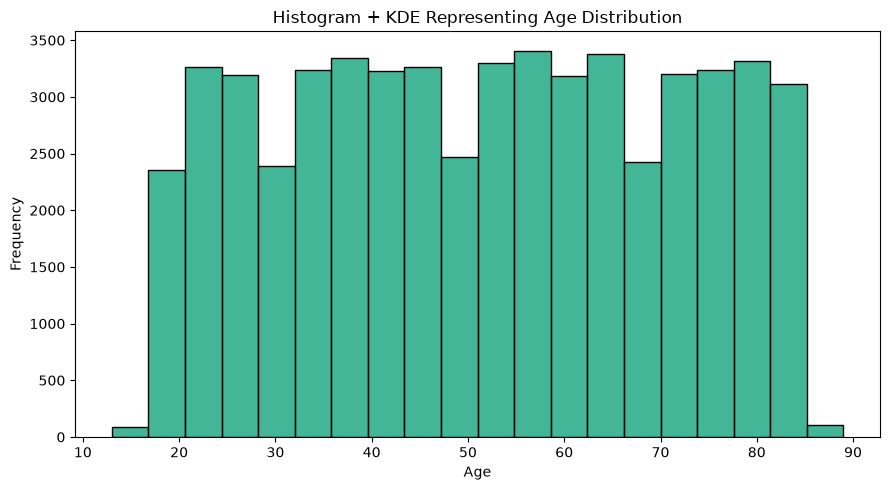

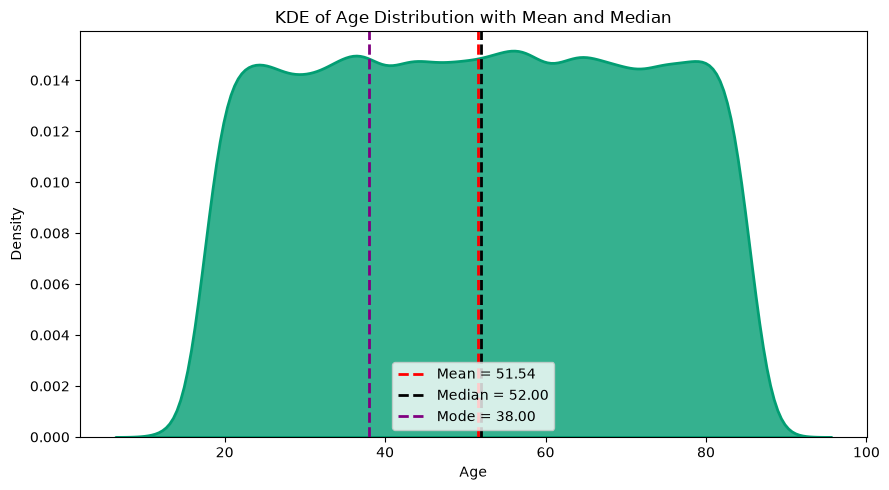

In [42]:
# Age histogram with KDE (Univariate)

COLOR = sns.color_palette("colorblind")[2]

plt.figure(figsize=(9, 5))
sns.histplot(data=df, x="Age", bins=20, color=COLOR, edgecolor="black")

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Histogram + KDE Representing Age Distribution")
plt.tight_layout()
plt.savefig("figures/Figure_1_Histogram_Age_Distribution.png",
            dpi=300, bbox_inches="tight")
plt.show()


colors = sns.color_palette("colorblind")
COLOR = colors[2]

mean_age = df["Age"].mean()
median_age = df["Age"].median()
mode_age = df["Age"].mode()[0]

plt.figure(figsize=(9, 5))

# KDE
sns.kdeplot(
    df["Age"],
    color=COLOR,
    linewidth=2,
    alpha=0.8,
    fill=True
)

# Mean line
plt.axvline(
    mean_age,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_age:.2f}"
)

# Median line
plt.axvline(
    median_age,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_age:.2f}"
)

# Mode line
plt.axvline(
    mode_age,
    color="purple",
    linestyle="--",
    linewidth=2,
    label=f"Mode = {mode_age:.2f}"
)

plt.xlabel("Age")
plt.ylabel("Density")
plt.title("KDE of Age Distribution with Mean and Median")

plt.legend()
plt.tight_layout()

plt.savefig("figures/Figure_1_Age_KDE_Distribution.png",
            dpi=300, bbox_inches="tight")

plt.show()

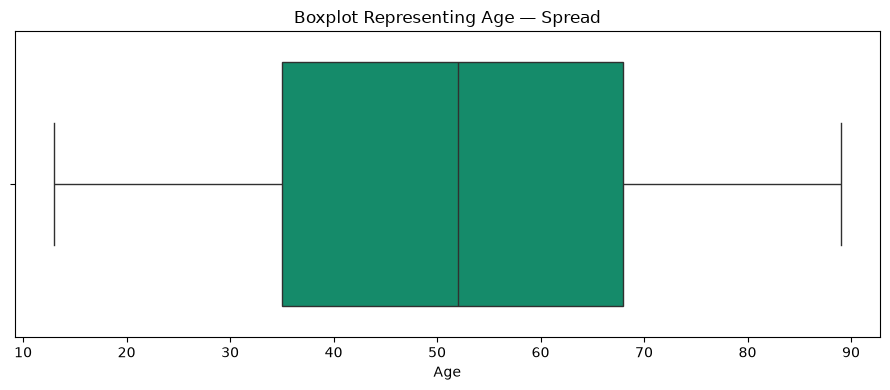

Minimum: 13
Maximum: 89
Median: 52.0
25th percentile: 35.0
75th percentile: 68.0
IQR: 33.0


In [43]:
# Age Spread (to show IQR, whiskers = range (excluding outliers), dots = outlier) (univariate)

COLOR=sns.color_palette("colorblind")[2]

plt.figure(figsize=(9, 4))
sns.boxplot(x=df["Age"], color=COLOR)
plt.xlabel("Age")
plt.title("Boxplot Representing Age — Spread")
plt.tight_layout()

plt.savefig("figures/Figure_2_Boxplot_Representing_Age_Spread.png",
            dpi=300, bbox_inches="tight")
plt.show()


print("Minimum:", df["Age"].min())
print("Maximum:", df["Age"].max())
print("Median:", df["Age"].median())        
print("25th percentile:", df["Age"].quantile(0.25))      # 25th percentile
print("75th percentile:", df["Age"].quantile(0.75))      # 75th percentile
print("IQR:", df["Age"].quantile(0.75) - df["Age"].quantile(0.25))    # Interquartile Range

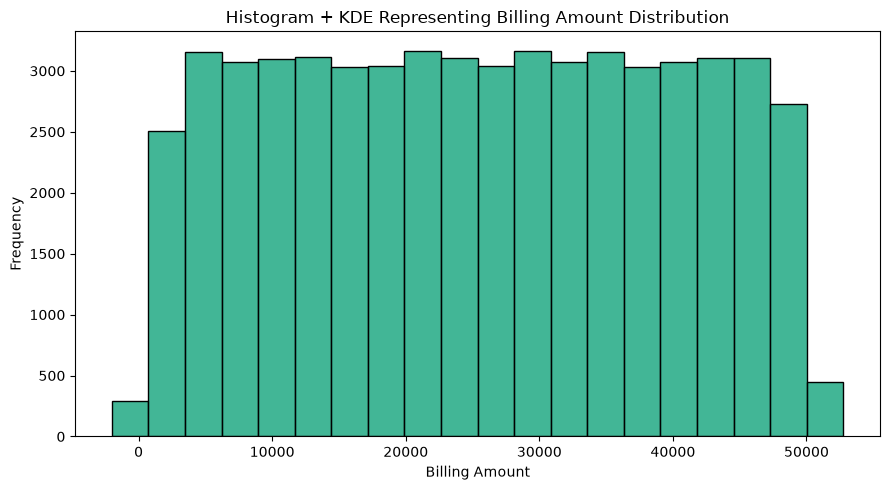

<Figure size 900x500 with 0 Axes>

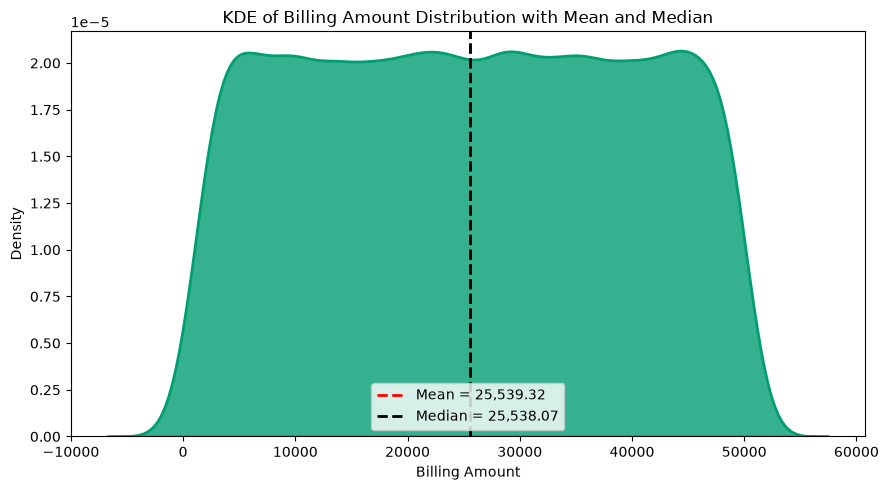

In [44]:
# Billing Amount histogram with KDE (Univariate)

COLOR = sns.color_palette("colorblind")[2]

plt.figure(figsize=(9, 5))
sns.histplot(data=df, x="Billing Amount", bins=20, color=COLOR, edgecolor="black")

plt.xlabel("Billing Amount")
plt.ylabel("Frequency")
plt.title("Histogram + KDE Representing Billing Amount Distribution")
plt.tight_layout()
plt.savefig("figures/Figure_3_Histogram_Age_Distribution.png",
            dpi=300, bbox_inches="tight")
plt.show()


colors = sns.color_palette("colorblind")
COLOR = colors[2]

mean_age = df["Age"].mean()
median_age = df["Age"].median()

plt.figure(figsize=(9, 5))


colors = sns.color_palette("colorblind")
COLOR = colors[2]

mean_billing = df["Billing Amount"].mean()
median_billing = df["Billing Amount"].median()

plt.figure(figsize=(9, 5))

# KDE
sns.kdeplot(
    df["Billing Amount"],
    color=COLOR,
    linewidth=2,
    alpha=0.8,
    fill=True
)

# Mean line
plt.axvline(
    mean_billing,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_billing:,.2f}"
)

# Median line
plt.axvline(
    median_billing,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_billing:,.2f}"
)

plt.xlabel("Billing Amount")
plt.ylabel("Density")
plt.title("KDE of Billing Amount Distribution with Mean and Median")

plt.legend()
plt.tight_layout()

plt.savefig("figures/Figure_3_Billing_Amount_KDE_Distribution.png",
            dpi=300, bbox_inches="tight")

plt.show()

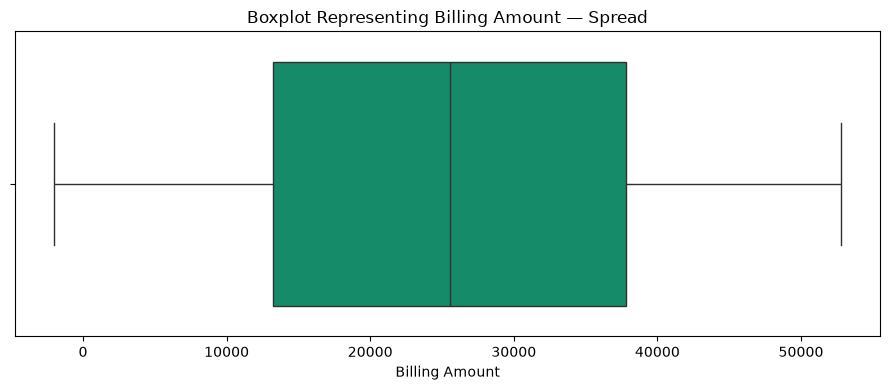

Minimum: -2008.4921398591305
Maximum: 52764.276736469175
Median: 25538.069375965664
25th percentile: 13241.224652365136
75th percentile: 37820.508435784795
IQR: 24579.28378341966


In [45]:
# Billing Amount Spread (to show IQR, whiskers = range (excluding outliers), dots = outlier) (univariate)

COLOR=sns.color_palette("colorblind")[2]

plt.figure(figsize=(9, 4))
sns.boxplot(x=df["Billing Amount"], color=COLOR)
plt.xlabel("Billing Amount")
plt.title("Boxplot Representing Billing Amount — Spread")
plt.tight_layout()
plt.savefig("figures/Figure_4_Boxplot_Representing_Billing_Amount_Spread.png",
            dpi=300, bbox_inches="tight")
plt.show()


print("Minimum:", df["Billing Amount"].min())
print("Maximum:", df["Billing Amount"].max())
print("Median:", df["Billing Amount"].median())        
print("25th percentile:", df["Billing Amount"].quantile(0.25))      # 25th percentile
print("75th percentile:", df["Billing Amount"].quantile(0.75))      # 75th percentile
print("IQR:", df["Billing Amount"].quantile(0.75) - df["Billing Amount"].quantile(0.25))    # Interquartile Range

2. Visual Analysis of Categorical Variable 

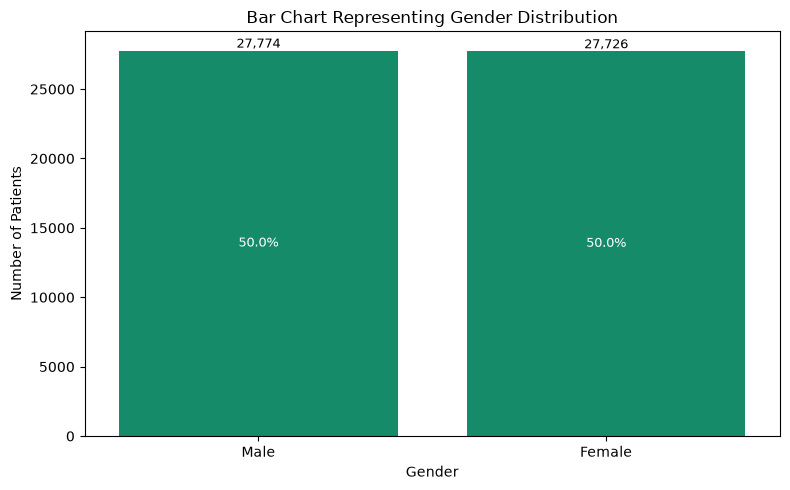

In [47]:
# Gender distribution (Univariate)

COLOR = sns.color_palette("colorblind")[2]

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Gender",
    color=COLOR
)

total = len(df)

for p in ax.patches:
    count = int(p.get_height())
    percentage = count / total * 100

    # Count above the bar
    ax.annotate(
        f"{count:,}",
        (p.get_x() + p.get_width()/2, count),
        ha="center",
        va="bottom",
        fontsize=9
    )

    # Percentage inside the bar
    ax.annotate(
        f"{percentage:.1f}%",
        (p.get_x() + p.get_width()/2, count / 2),
        ha="center",
        va="center",
        fontsize=9,
        color="white"
    )

plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.title("Bar Chart Representing Gender Distribution")
plt.tight_layout()

plt.savefig("figures/Figure_5_Bar_Chart_Representing_Gender_Distribution.png",
            dpi=300, bbox_inches="tight")

plt.show()

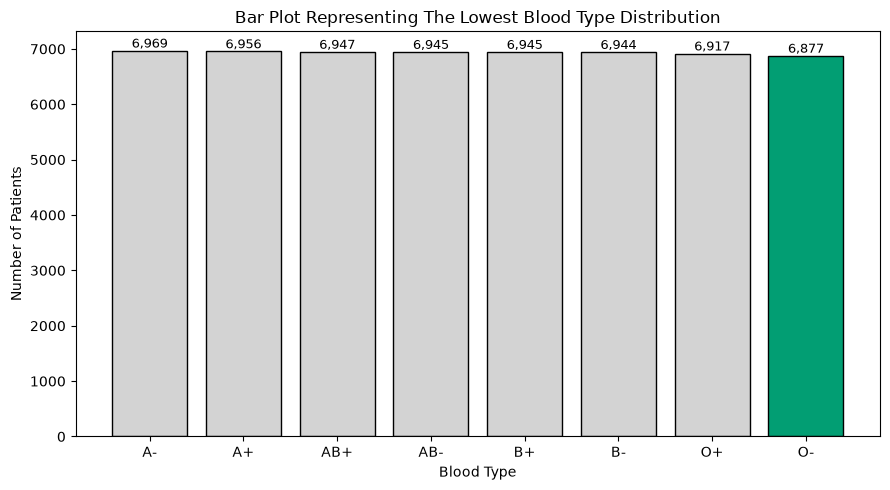

In [48]:
# Count each blood type (univariate)

blood_counts = df["Blood Type"].value_counts()

# Identify the most frequent blood type
lowest_blood_type = blood_counts.idxmin()

# Green for the highest, gray for the others
COLOR = sns.color_palette("colorblind")[2]

bar_colors = [
    COLOR if blood_type == lowest_blood_type else "lightgray"
    for blood_type in blood_counts.index
]

plt.figure(figsize=(9, 5))

bars = plt.bar(
    blood_counts.index,
    blood_counts.values,
    color=bar_colors,
    edgecolor="black"
)

# Add frequency labels
for bar, value in zip(bars, blood_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xlabel("Blood Type")
plt.ylabel("Number of Patients")
plt.title("Bar Plot Representing The Lowest Blood Type Distribution")
plt.tight_layout()

plt.savefig("figures/Figure_6_Barplot_Representing_Blood_Type_Distribution.png",
            dpi=300, bbox_inches="tight")

plt.show()

3. Relationships/Comparison 

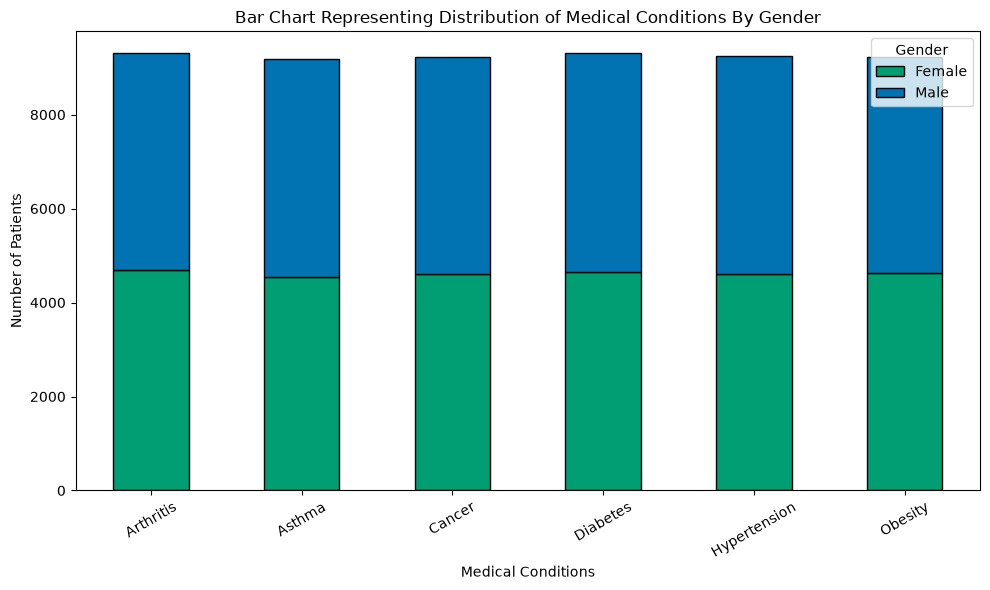

In [50]:
# distribution of gender across medical conditions (Bivariate)

gender_condition = pd.crosstab(
    df["Medical Condition"],
    df["Gender"]
)

# Colorblind-friendly colours
colors = sns.color_palette("colorblind")

# Create stacked bar chart
gender_condition.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=[colors[2], colors[0]],
    edgecolor="black"
)

plt.xlabel("Medical Conditions")
plt.ylabel("Number of Patients")
plt.title("Bar Chart Representing Distribution of Medical Conditions By Gender")
plt.xticks(rotation=30)
plt.legend(title="Gender")
plt.tight_layout()


plt.savefig("figures/Figure_7_Bar_Chart_Representing_Distribution_of_Medical_Conditions_By_Gender.png",
            dpi=300, bbox_inches="tight")

plt.show()

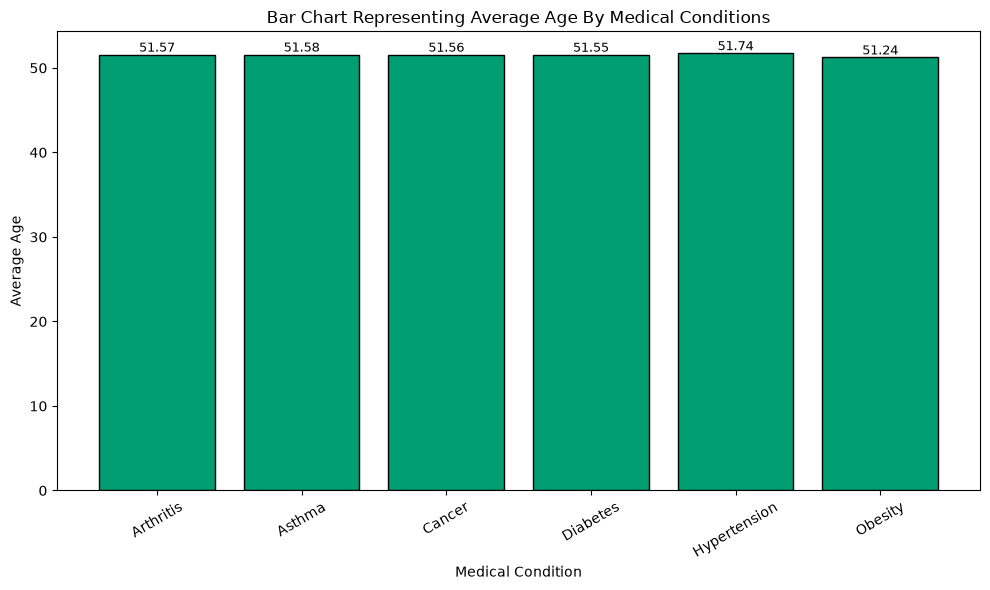

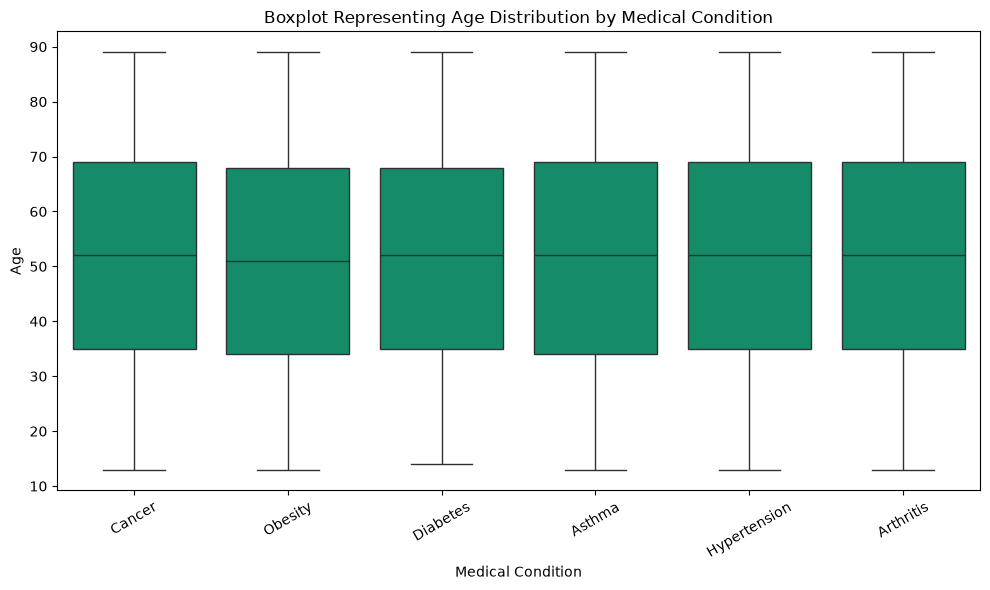

In [51]:
# visualizing age by medical condition (Bivariate)

COLOR = sns.color_palette("colorblind")[2]

average_age = df.groupby("Medical Condition")["Age"].mean()

plt.figure(figsize=(10, 6))

bars = plt.bar(
    average_age.index,
    average_age.values,
    color=COLOR,
    edgecolor="black"
)

for bar, value in zip(bars, average_age.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xlabel("Medical Condition")
plt.ylabel("Average Age")
plt.title("Bar Chart Representing Average Age By Medical Conditions")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("figures/Figure_8_Bar Chart_Representing_Average_Age_By_Medical_Conditions.png",
            dpi=300, bbox_inches="tight")
plt.show()


# boxplot
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Medical Condition",
    y="Age",
    color=sns.color_palette("colorblind")[2]
)

plt.xlabel("Medical Condition")
plt.ylabel("Age")
plt.title("Boxplot Representing Age Distribution by Medical Condition")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig("figures/Figure_8_Boxplot_Representing_Average_Age_By_Medical_Conditions.png",
            dpi=300, bbox_inches="tight")

plt.show()

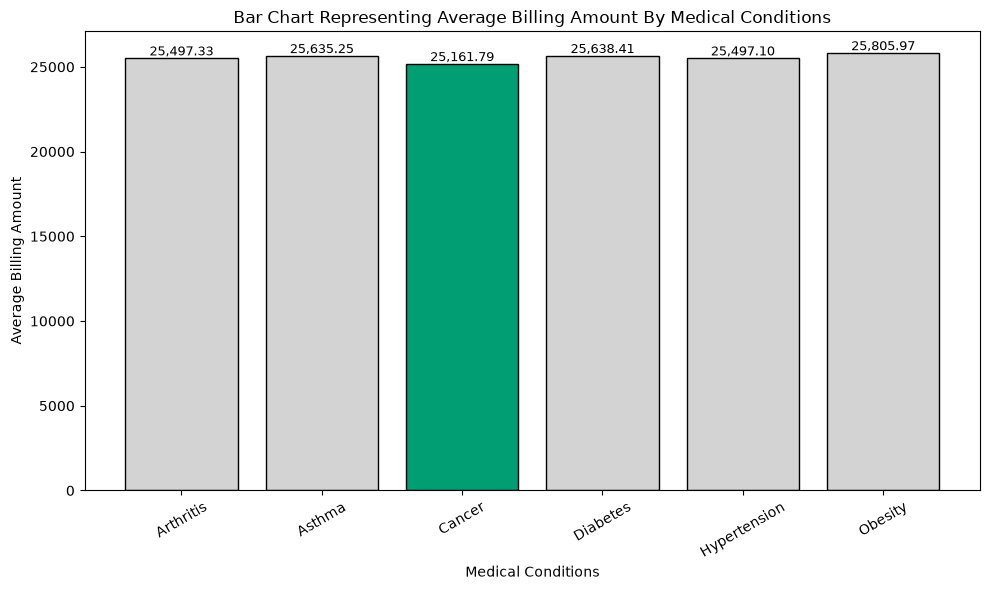

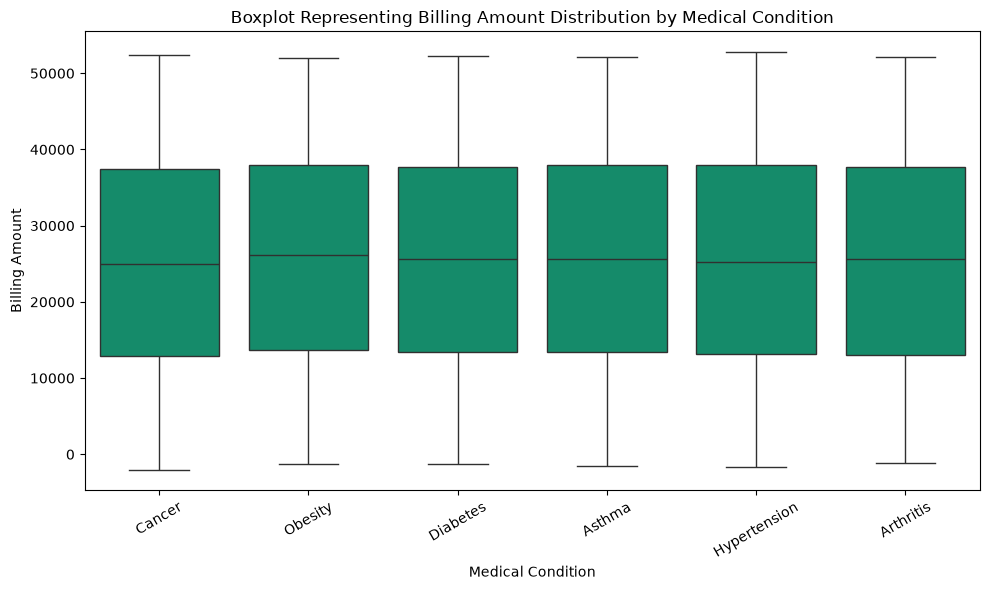

In [52]:
# visualizing billing amounts by medical condition (Bivariate)

COLOR = sns.color_palette("colorblind")[2]

# Calculate average billing amount for each medical condition
average_billing = df.groupby("Medical Condition")["Billing Amount"].mean()

# Identify the smallest medical condition
smallest_condition = average_billing.idxmin()
smallest_value = average_billing.min()

# Make all bars gray except the smallest
bar_colors = [
    COLOR if condition == smallest_condition else "lightgray"
    for condition in average_billing.index
]

# Create bar chart
plt.figure(figsize=(10, 6))

bars = plt.bar(
    average_billing.index,
    average_billing.values,
    color=bar_colors,
    edgecolor="black"
)

# Display the value on every bar
for bar, value in zip(bars, average_billing.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )



plt.xlabel("Medical Conditions")
plt.ylabel("Average Billing Amount")
plt.title("Bar Chart Representing Average Billing Amount By Medical Conditions")

plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("figures/Figure_9_Bar_chart_Representing_Average_Billing_Amount_By_Medical_Conditions.png",
            dpi=300, bbox_inches="tight")
plt.show()

# box plot
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Medical Condition",
    y="Billing Amount",
    color=sns.color_palette("colorblind")[2]
)

plt.xlabel("Medical Condition")
plt.ylabel("Billing Amount")
plt.title("Boxplot Representing Billing Amount Distribution by Medical Condition")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig("figures/Figure_9_Boxplot_Representing_Average_Billing_Amount_By_Medical_Conditions.png",
            dpi=300, bbox_inches="tight")

plt.show()

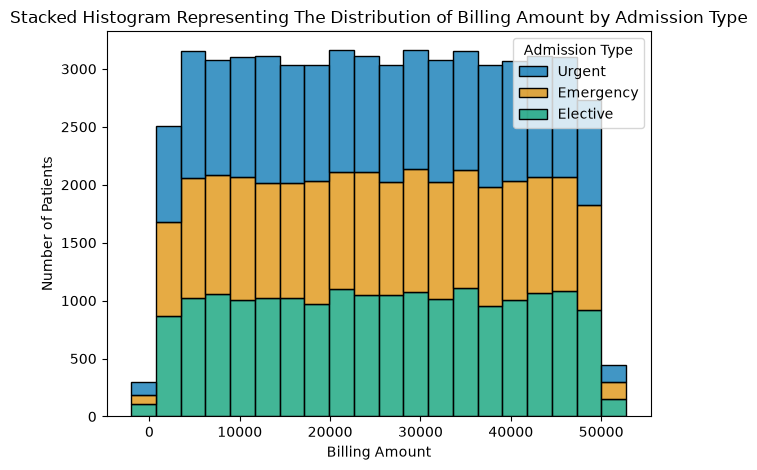

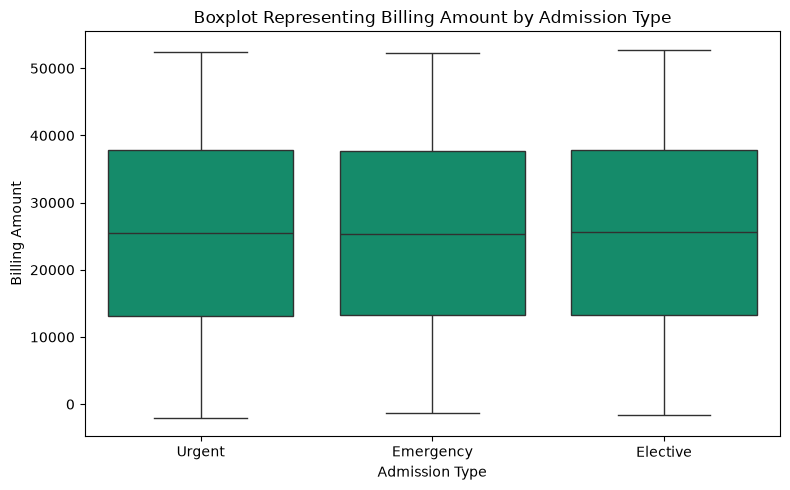

In [53]:
# Stacked histogram showing Billing Amount distribution by Admission Type (Bivariate)

sns.histplot(
    data=df,
    x="Billing Amount",
    bins=20,
    hue="Admission Type",
    multiple="stack",
    palette="colorblind",
    edgecolor="black"
)

plt.xlabel("Billing Amount")
plt.ylabel("Number of Patients")
plt.title("Stacked Histogram Representing The Distribution of Billing Amount by Admission Type")
plt.tight_layout()
plt.savefig("figures/Figure_10_Stacked_Histogram_Representing_Billing_Amount_by_Admission_Type.png",
            dpi=300, bbox_inches="tight")
plt.show()


# boxplot

COLOR = sns.color_palette("colorblind")[2]

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Admission Type", y="Billing Amount",color=COLOR)
plt.xlabel("Admission Type")
plt.ylabel("Billing Amount")
plt.title("Boxplot Representing Billing Amount by Admission Type")
plt.tight_layout()


plt.savefig("figures/Figure_10_Boxplot_Representing_Billing_Amount_by_Admission_Type.png",
            dpi=300, bbox_inches="tight")
plt.show()

4. COVARIANCE

In [55]:
# Age vs Billing Amount

print("cov_matrix:",  df[["Age", "Billing Amount"]].cov())     # covariance


cov_matrix:                         Age  Billing Amount
Age              384.256195   -1.067500e+03
Billing Amount -1067.500056    2.019654e+08


5. CORRELATION

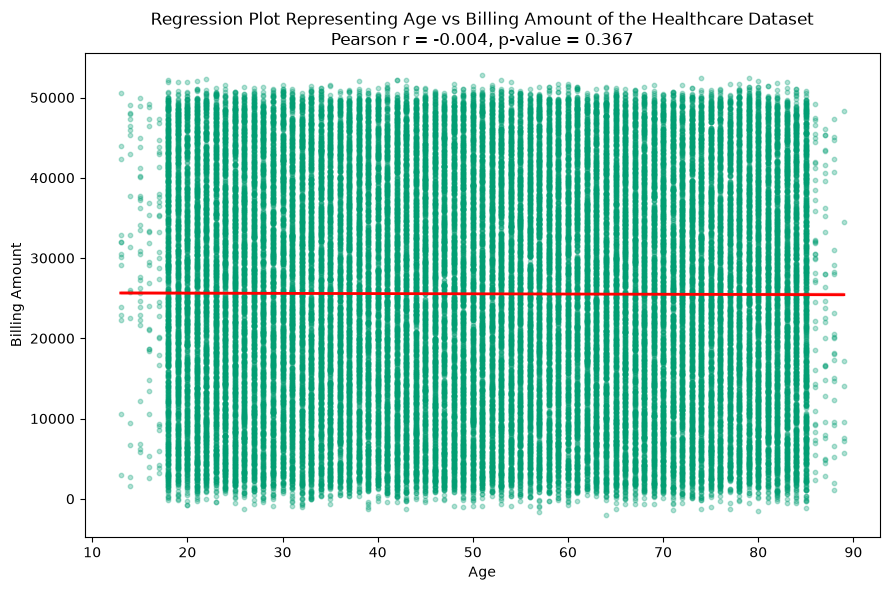

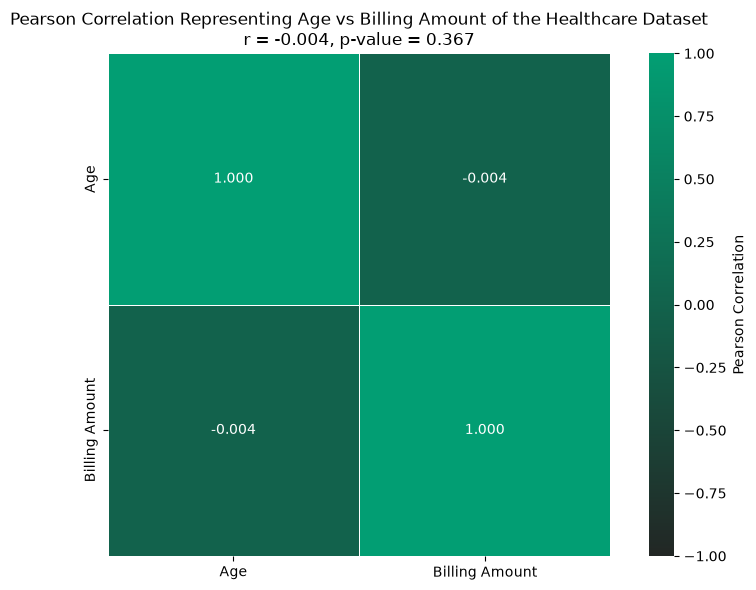

In [57]:
# Correlation of numerical variables for Age and Billing Amount (Bivariate)

from scipy.stats import pearsonr

# Select the two numerical variables
data = df[["Age", "Billing Amount"]]

# Calculate Pearson correlation and p-value
r, p = pearsonr(data["Age"], data["Billing Amount"])

# Colour settings
COLOR = sns.color_palette("colorblind")[2]
DARK_GREEN = sns.dark_palette(COLOR, reverse=False, as_cmap=True)


# --------------------------------------------------
# Regression Plot
# --------------------------------------------------

plt.figure(figsize=(9, 6))

sns.regplot(
    data=df,
    x="Age",
    y="Billing Amount",
    scatter_kws={"alpha": 0.3, "s": 10, "color": COLOR},
    line_kws={"color": "red", "lw": 2}
)

plt.xlabel("Age")
plt.ylabel("Billing Amount")

plt.title(
    f"Regression Plot Representing Age vs Billing Amount of the Healthcare Dataset\n"
    f"Pearson r = {r:.3f}, p-value = {p:.3g}"
)

plt.tight_layout()

plt.savefig(
    "figures/Figure_11_Regression_Plot_Age_Billing_Amount.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# --------------------------------------------------
# Pearson Correlation Heatmap
# --------------------------------------------------

corr = data.corr(method="pearson")

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap=DARK_GREEN,
    center=0,
    fmt=".3f",
    square=True,
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    cbar_kws={"label": "Pearson Correlation"}
)

plt.title(
    f"Pearson Correlation Representing Age vs Billing Amount of the Healthcare Dataset\n"
    f"r = {r:.3f}, p-value = {p:.3g}"
)

plt.tight_layout()

plt.savefig(
    "figures/Figure_11_Pearson_Correlation_Age_Billing_Amount.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

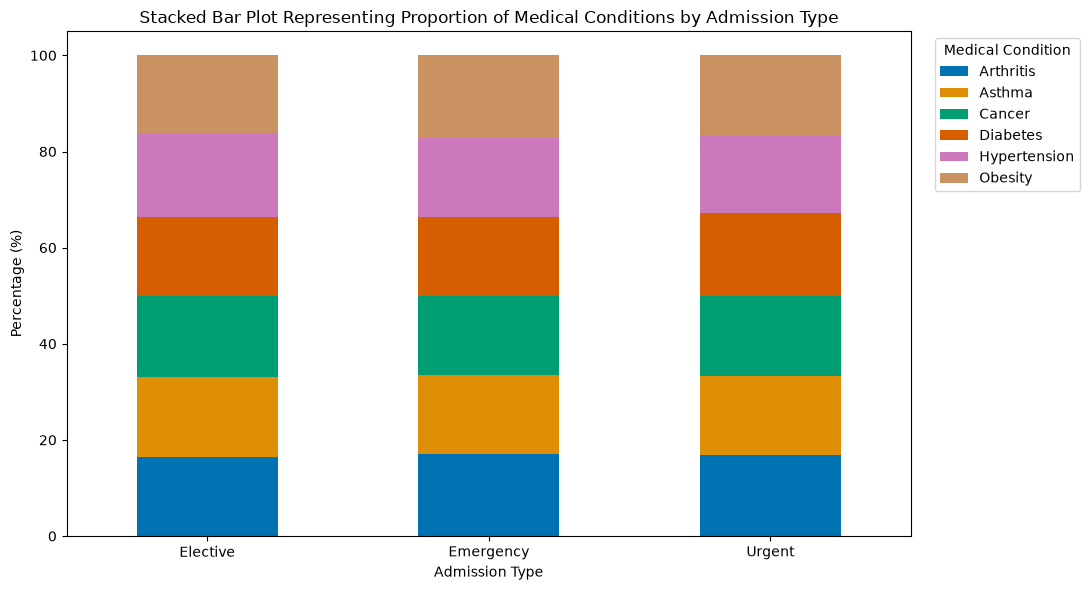

In [58]:
# comparing distribution against groups

ct = pd.crosstab(
    df["Admission Type"],
    df["Medical Condition"])

ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

ct_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6),
    color=sns.color_palette("colorblind", n_colors=ct.shape[1])
)

plt.xlabel("Admission Type")
plt.ylabel("Percentage (%)")
plt.title("Stacked Bar Plot Representing Proportion of Medical Conditions by Admission Type")
plt.xticks(rotation=0)
plt.legend(title="Medical Condition", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("figures/Figure_12_Stacked_Barplot_Representing_Proportion_of_Medical_Coditions_by_Admission_Type.png",
            dpi=300, bbox_inches="tight")
plt.show()



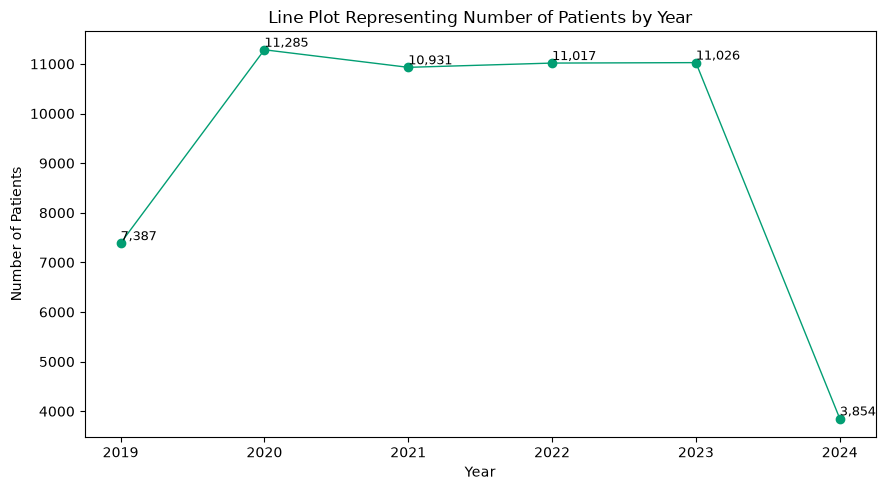

In [59]:
# Extract year from Date of Admission

df["Year"] = df["Date of Admission"].dt.year

# Count patients per year
year_counts = df["Year"].value_counts().sort_index()

plt.figure(figsize=(9, 5))

plt.plot(
    year_counts.index,
    year_counts.values,
    marker="o",
    color=sns.color_palette("colorblind")[2],
    linewidth=1
)

# Add values to each point
for year, value in zip(year_counts.index, year_counts.values):
    plt.text(
        year,
        value,
        f"{value:,}",
        ha="left",
        va="bottom",
        fontsize=9
    )

plt.xlabel("Year")
plt.ylabel("Number of Patients")
plt.title("Line Plot Representing Number of Patients by Year")

plt.tight_layout()
plt.savefig("figures/Figure_13_Line_plot_Representing_Number_of-Patients_Per-Year.png",
            dpi=300, bbox_inches="tight")
plt.show()
